### First run the main notebook

In [26]:
%%capture
%run ./Image_processing_fundamentals_pt1.ipynb

## Thresholding bacteria

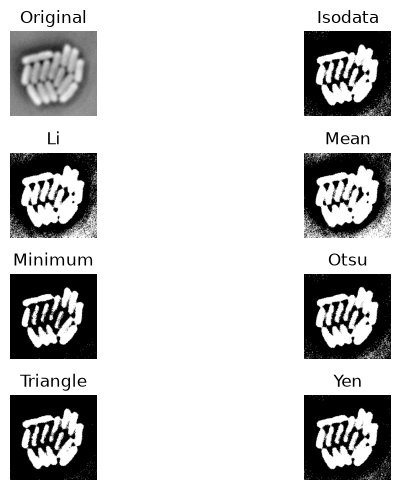

In [10]:
_ = sk.filters.try_all_threshold(img_ecoli, verbose=False)

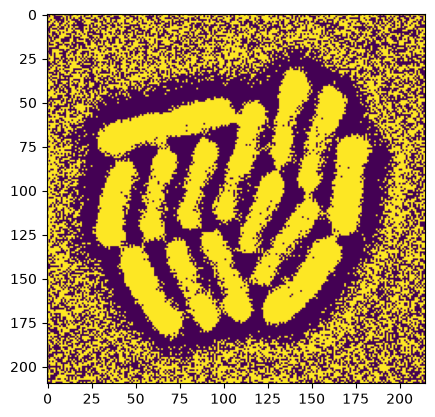

In [18]:
_ = plt.imshow(img_ecoli>sk.filters.threshold_local(img_ecoli, block_size=35, offset=0))

### Conclusion

Some of these results are not bad, but none are directly usable. We'll need more techniques to segment these bacteria.

## Opening and closing

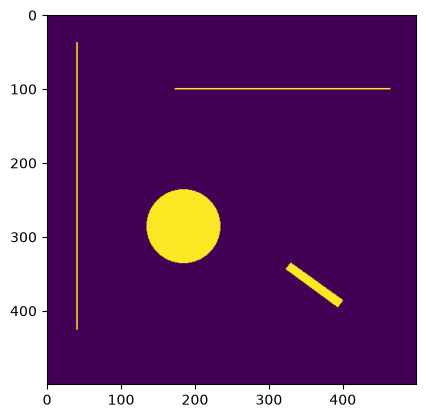

In [20]:
# Morphological closing (dilation followed by erosion)
img_pika_closed = \
    sk.morphology.closing(
        img_pika,
        footprint=sk.morphology.disk(7)
    )

# Show the result
_ = plt.imshow(img_pika_closed) 
plt.show()

This filled the "hole" in the big circle. The footprint modification is needed to achieve this.

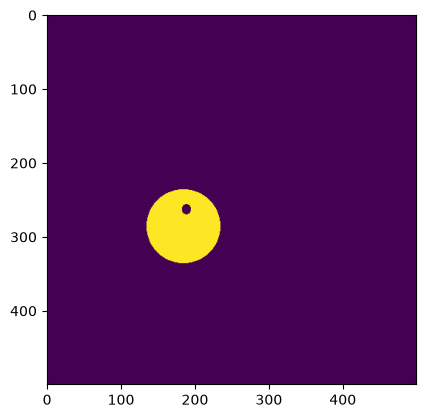

In [22]:
# Morphological opening (erosion followed by dilation)
img_pika_opened = \
    sk.morphology.opening(
        img_pika, 
        footprint=sk.morphology.disk(7)
    )

_ = plt.imshow(img_pika_opened)
plt.show()

This removed everything (due to dilation), but kept the large structure. Also here, depending on the footprint size, different structures remain.

## Thresholding

### Nuclear edges

> "Can you create a mask that contains the edges of (`img_nuclei`), using `img_edges`?"

You can play around with different methods, local thresholding works pretty well with certain parameters.

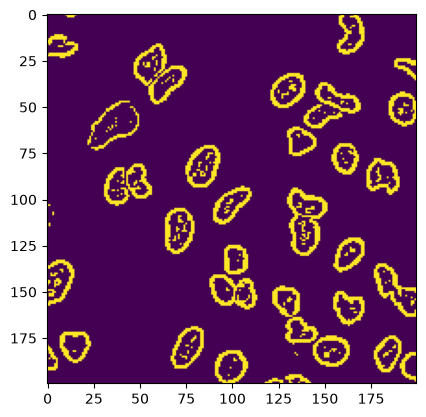

In [46]:

mask_nuclei_edge = img_edges[0:200,0:200]>sk.filters.threshold_local(img_edges[0:200,0:200], block_size=11, offset=-.001)
_ = plt.imshow(mask_nuclei_edge)

### Nuclear edges (option 2)

A more sophisticated approach combines a few things you've learned, and another method to remove small areas.

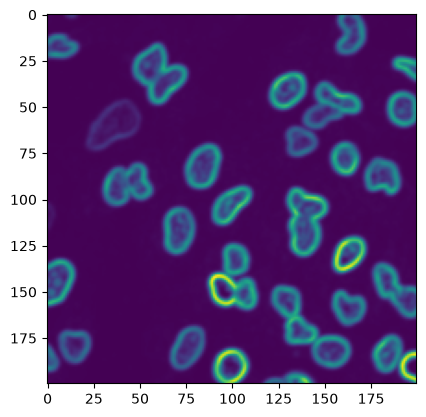

In [ ]:
# blur to remove noise
img_edges_blurred = sk.filters.gaussian(img_edges, sigma=1)
# show the result
_ = plt.imshow(img_edges_blurred[0:200,0:200])


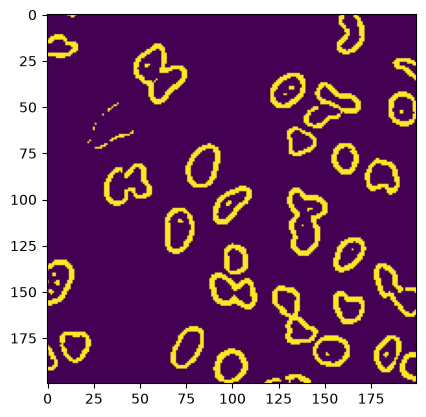

In [53]:
# Apply a local filter
mask_nuclei_edge2 = img_edges_blurred[0:200,0:200]>sk.filters.threshold_local(img_edges_blurred[0:200,0:200], block_size=11, offset=-.001)
_ = plt.imshow(mask_nuclei_edge2)

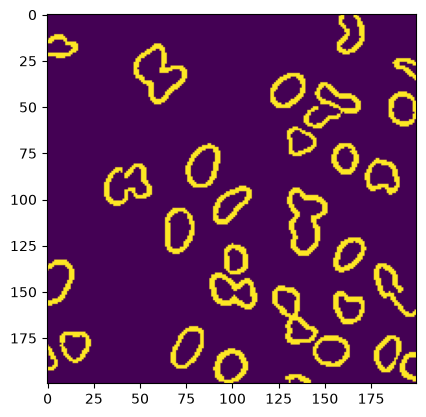

In [62]:
# Remove small parts
mask_nuclei_edge2_cleaned = sk.morphology.remove_small_objects(mask_nuclei_edge2, max_size=25)
_ = plt.imshow(mask_nuclei_edge2_cleaned)


### Conclusion:
Not perfect, but works pretty well.
You might even be able to optimize this further.

### Identifying points

> "Can you create a binary mask for the points in `img_noisy`?"

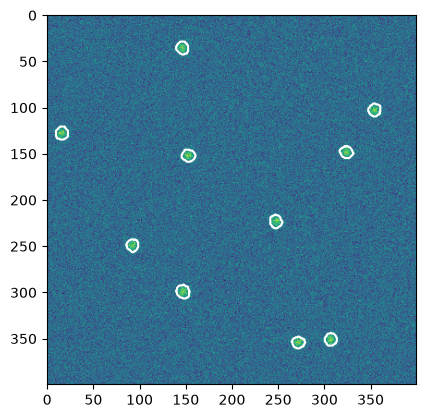

In [ ]:
# Obtain a mask using simple Otsu threshold applied to median filtered image
# The median filtered image will contain high medians only when there was a local
# concentration of higher values, ie the spots.
mask_points = img_noisy_median>sk.filters.threshold_otsu(img_noisy_median)

# Show result
_ = plt.imshow(img_noisy)
_ = plt.contour(mask_points, colors='w', levels=[0.5]) 
    # plt.contour draws isolines at given levels, sometimes convenient for showing segmentation